# LangGraph 입문 데모 노트북

이 노트북은 **상태(state) 기반으로 흘러가는 작은 무대극 그래프**를 보여줍니다.

이번 버전은 다음 목표를 반영했습니다.
- 모든 메모/대사/감수 결과를 한국어로 생성
- K-팝 데몬 헌터 전제 유지
- 감수 결과가 실제로 `writer` 또는 `manager` 재진입을 만들 수 있게 개선
- 코드 구조는 여전히 초보자 친화적으로 유지


In [1]:
from __future__ import annotations

import os
import sys
import traceback
from pathlib import Path

from dotenv import load_dotenv

candidate = Path.cwd()
project_root = candidate if (candidate / 'src').exists() else candidate.parent
sys.path.insert(0, str(project_root))
load_dotenv(project_root / '.env')
os.environ.setdefault('TARGET_DIALOGUE_TURNS', '6')

from src.langgraph_novel_lab.main import build_graph, print_result, run_demo, target_turns

print('project_root =', project_root)
def mask_secret(value: str | None, visible: int = 4) -> str:
    if not value:
        return '(unset)'
    if len(value) <= visible:
        return '*' * len(value)
    return f"{value[:visible]}… (len={len(value)})"

print('OPENAI_BASE_URL =', os.getenv('OPENAI_BASE_URL'))
print('OPENAI_API_KEY =', mask_secret(os.getenv('OPENAI_API_KEY')))
print('OPENAI_MODEL =', os.getenv('OPENAI_MODEL'))
print('target_turns =', target_turns())


project_root = c:\Users\yeope\yeounhyeok\projectWorkspace\langgraph-novel-lab
OPENAI_BASE_URL = https://api.openai.com/v1
OPENAI_API_KEY = sk-p… (len=164)
OPENAI_MODEL = gpt-5-mini
target_turns = 6


## 1) 상태와 입력 전제

이번 데모의 전제는 유지합니다.

> 낮에는 화려한 K-팝 아이돌 그룹 '루미너스'로 활동하지만, 밤에는 음악의 주파수로 도시를 잠식하는 악령들을 사냥하는 데몬 헌터들의 사투와 두 리더의 갈등.

LangGraph 핵심은 **누가 다음에 말할지**를 `next_node`와 `turns`로 결정한다는 점입니다.


In [3]:
premise = "화려한 케이팝 걸그룹 '헌트릭스(HUNTR/X)' 멤버들이 밤에는 세상을 위협하는 악령을 물리치는 데몬 헌터로 변신하는 판타지 액션물입니다. 3인조 걸그룹 루미, 미라, 조이가 노래와 퍼포먼스, 한국 전통 무기를 활용해 악귀를 퇴치하는 이중생활을 그립니다. 핵심 설정 및 시놉시스 이중생활: 낮에는 세계적인 슈퍼스타 케이팝 걸그룹, 밤에는 악마를 사냥하여 인간 세상을 지키는 헌터. 전투 방식: 헌트릭스는 악령들을 물리치고 이들을 봉인하는 '황금 혼문(魂門)'을 만들기 위해 노래와 춤을 무기로 사용. 대립 구조: 팬들의 영혼을 빼앗으려는 라이벌 악령 보이 그룹 '사자 보이즈(Saja Boys)'와 대결. 한국적 요세: 멤버들은 각각 사인검, 월도, 신카이 등 한국 전통 무기를 개성 있게 사용."

initial_state = {
    'premise': premise,
    'dialogue_history': [],
    'turns': 0,
    'next_node': 'manager',
}

initial_state

{'premise': "화려한 케이팝 걸그룹 '헌트릭스(HUNTR/X)' 멤버들이 밤에는 세상을 위협하는 악령을 물리치는 데몬 헌터로 변신하는 판타지 액션물입니다. 3인조 걸그룹 루미, 미라, 조이가 노래와 퍼포먼스, 한국 전통 무기를 활용해 악귀를 퇴치하는 이중생활을 그립니다. 핵심 설정 및 시놉시스 이중생활: 낮에는 세계적인 슈퍼스타 케이팝 걸그룹, 밤에는 악마를 사냥하여 인간 세상을 지키는 헌터. 전투 방식: 헌트릭스는 악령들을 물리치고 이들을 봉인하는 '황금 혼문(魂門)'을 만들기 위해 노래와 춤을 무기로 사용. 대립 구조: 팬들의 영혼을 빼앗으려는 라이벌 악령 보이 그룹 '사자 보이즈(Saja Boys)'와 대결. 한국적 요세: 멤버들은 각각 사인검, 월도, 신카이 등 한국 전통 무기를 개성 있게 사용.",
 'dialogue_history': [],
 'turns': 0,
 'next_node': 'manager'}

## 2) 그래프 만들기

이 프로젝트의 그래프는 다음 흐름을 가집니다.

`manager -> director -> character_a <-> character_b -> writer -> auditor`

중요한 점은 `character_a`와 `character_b`가 고정 길이 파이프라인이 아니라, **상태를 보고 라우팅**된다는 것입니다.

그리고 이번 버전에서는 `auditor`도 끝맺는 역할만 하지 않습니다.
감수 결과가 부족하다고 판단되면 `writer` 또는 `manager`로 되돌려서 **한 번 더 고쳐 쓰게** 할 수 있습니다.


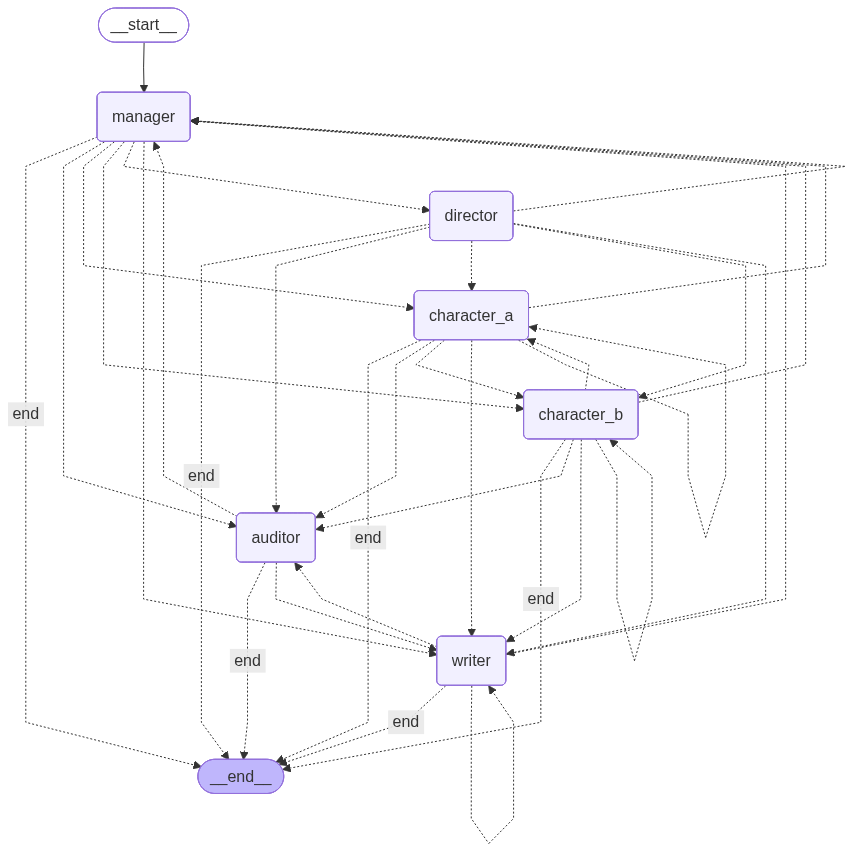

In [4]:
app = build_graph()
app

## 3) 실제 실행

아래 셀은 전체 그래프를 한 번 실행합니다.
출력 로그에서 각 노드가 어떤 순서로 진행되는지 볼 수 있습니다.

In [5]:
result = await run_demo(premise)
#print_result(result)

[llm] role=manager provider=openai model=gpt-5-mini elapsed_ms=21078 output_chars=1419
[manager] revision_count=0 next_node=director
[manager] notes
- 장면 톤: 한밤의 콘서트와 전투가 겹쳐지는 하이브리드한 긴장감. 무대의 네온과 스포트라이트가 암흑 속 유령들을 환하게 드러내고, 팝 비트가 전투의 리듬으로 변하며 장면 전체가 음악적 서스펜스로 밀도 있게 흐른다. 화면은 화려한 퍼포먼스 샷(카메라 워킹, 군무의 정렬감)과 클로즈업(멤버들의 땀, 눈동자, 손에 쥔 전통무기)을 번갈아 보여주어 “무대 위 스타”와 “야간의 사냥꾼”이라는 이중 정체를 동시에 느끼게 한다. 분위기는 빠르게 고조되며, 순간순간 희망(팬들을 지켜야 한다)과 절박함(시간·기술의 제약)이 교차한다.

- 이번 장면의 위험/목표: 위험은 사자 보이즈가 앵콜 무대의 절정에서 팬들 마음 속 영혼 조각을 흡수하려는 계획을 실행에 옮기는 것. 동시에 무대 구조(높은 무대, 이동식 라이트·케이블, 폭죽 장치)와 관중의 대량 패닉이 2차 피해를 일으킬 가능성이 크다. 목표는 세 가지로 압축된다 — 1) 팬들의 영혼이 완전히 빼앗기기 전에 핵심 팬(어린 관객 한 명)의 영혼 조각을 보호, 2) 사자 보이즈 리더의 영혼 조각을 분리·유인해 루미의 노래로 황금 혼문을 열어 봉인, 3) 무대와 관중의 안전을 확보하며 신분 노출을 최소화. 제약: 황금 혼문은 ‘코러스 한 소절’ 동안만 안정적으로 열 수 있어 타이밍·안무·보컬 일치가 필수, 멤버 한 명이라도 위치나 음을 놓치면 봉인이 불안정해져 영혼 조각이 흩어질 위험이 있다.

- 구체적 긴장 요소 및 연출 포인트: 등장 신은 앵콜의 마지막 후렴에서 시작 — 사자 보이즈의 그림자 같은 백업 댄서들이 관중 속에서 모습을 드러내고, 무대 마이크로폰이 속삭이는 듯한 왜곡 음성을 퍼뜨린다. 루미는 사인검을 마이크 스탠드처럼 사용해 가창 라인을 지키려 하지

## 5) 학습 포인트

- 상태 객체 하나에 진행 정보가 모입니다.
- 각 노드는 상태 일부만 갱신합니다.
- 다음 노드는 `next_node`와 현재 state를 보고 정해집니다.
- 턴 수를 늘리는 것만이 아니라, 감수 결과를 다시 `writer`/`manager`에 넣어 장면 밀도를 높일 수 있습니다.
- 프롬프트 문구만 조정해도 **한국어 스타일, 감수 톤, 되돌아가는 노드**가 달라지는지 실험할 수 있습니다.
